# YUVAA Internship — Week 3
## Statistical Analysis and Agribusiness Forecasting

**Prepared by:** Avirup Karmakar

This notebook performs Week 3 statistical analysis and a simple annual production forecast using the cleaned crop-production dataset.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Prepare Data

In [2]:
df = pd.read_csv("crop_production.csv")

df.columns = df.columns.str.strip()

for c in ["State_Name", "District_Name", "Season", "Crop"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip()

for c in ["Crop_Year", "Area", "Production"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape:", df.shape)
display(df.head())


Shape: (246091, 8)


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [3]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("Duplicate rows:", df.duplicated().sum())

analysis_df = df.dropna(
    subset=["Crop_Year", "Area", "Production"]
).copy()

analysis_df = analysis_df[
    (analysis_df["Area"] >= 0) &
    (analysis_df["Production"] >= 0)
].copy()

print("Rows used for analysis:", len(analysis_df))


Missing values:


,Missing Values
index,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


Duplicate rows: 0
Rows used for analysis: 242361


## 3. Descriptive Statistics

In [4]:
display(
    analysis_df[["Area", "Production"]].describe()
)


,Area,Production
count,2.423610e+05,2.423610e+05
mean,1.216741e+04,5.825034e+05
std,5.085744e+04,1.706581e+07
min,1.000000e-01,0.000000e+00
25%,8.700000e+01,8.800000e+01
50%,6.030000e+02,7.290000e+02
75%,4.545000e+03,7.023000e+03
max,8.580100e+06,1.250800e+09


## 4. Pearson Correlation and Hypothesis Test

In [5]:
r, p_value = stats.pearsonr(
    analysis_df["Area"],
    analysis_df["Production"]
)

print(f"Pearson r = {r:.4f}")
print(f"p-value = {p_value:.6g}")

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0 at the 5% significance level.")
else:
    print("Decision: Fail to reject H0 at the 5% significance level.")


Pearson r = 0.0406
p-value = 6.80829e-89
Decision: Reject H0 at the 5% significance level.


### Hypotheses

**H0:** There is no linear relationship between Area and Production.

**H1:** There is a linear relationship between Area and Production.

The test uses α = 0.05.


## 5. Simple Linear Regression: Production ~ Area

In [6]:
X = analysis_df[["Area"]]
y = analysis_df["Production"]

reg_model = LinearRegression()
reg_model.fit(X, y)

y_pred = reg_model.predict(X)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Intercept:", reg_model.intercept_)
print("Area coefficient:", reg_model.coef_[0])
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


Intercept: 416788.04095455783
Area coefficient: 13.619606823028219
MAE: 1095705.5333389663
RMSE: 17051715.572238453
R²: 0.0016473434677568566


## 6. Regression Visualization

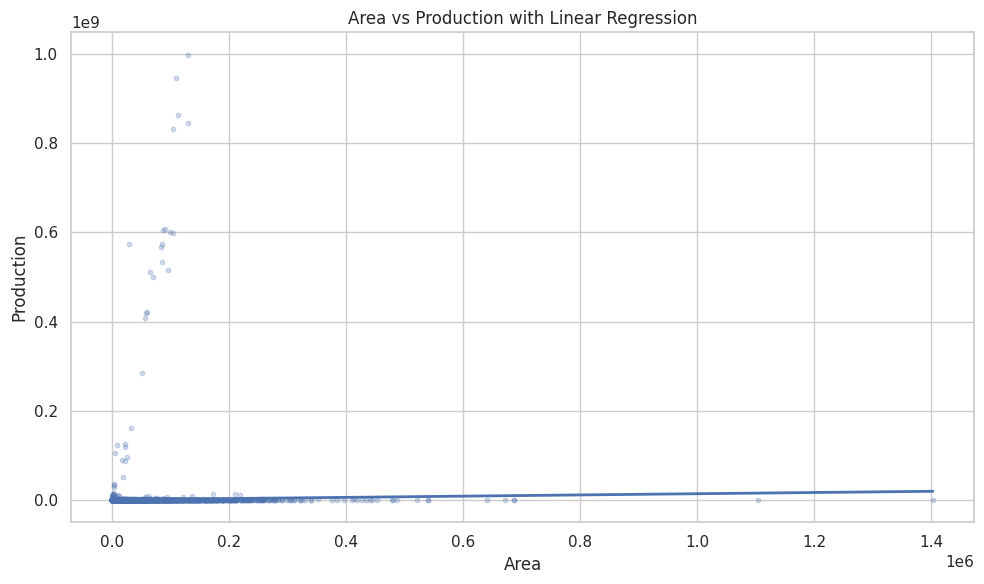

In [7]:
sample = analysis_df.sample(
    n=min(12000, len(analysis_df)),
    random_state=42
)

sample_pred = reg_model.predict(sample[["Area"]])

plt.figure(figsize=(10, 6))
plt.scatter(
    sample["Area"],
    sample["Production"],
    alpha=0.25,
    s=10
)

order = np.argsort(sample["Area"].values)

plt.plot(
    sample["Area"].values[order],
    sample_pred[order],
    linewidth=2
)

plt.title("Area vs Production with Linear Regression")
plt.xlabel("Area")
plt.ylabel("Production")
plt.tight_layout()
plt.show()


## 7. Residual Analysis

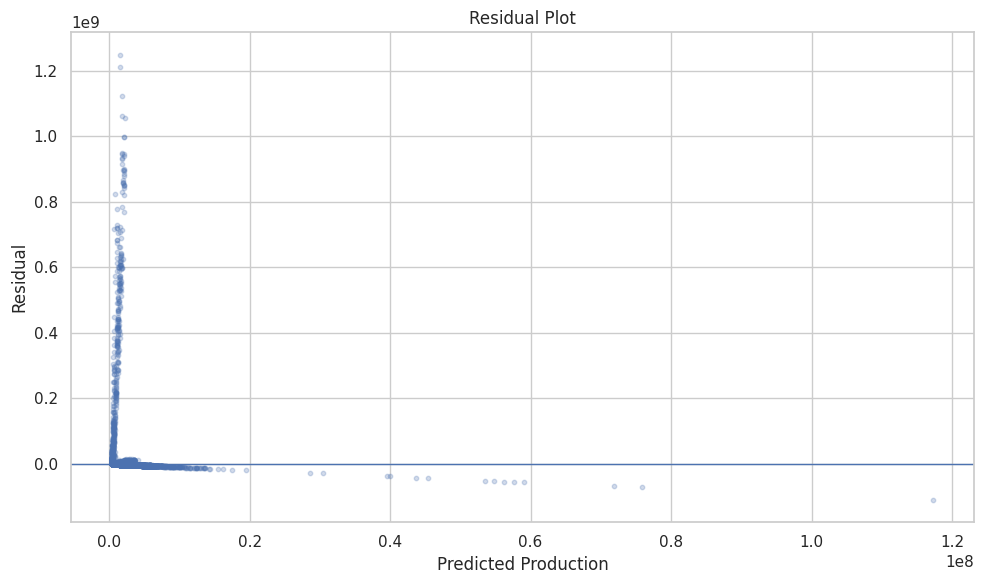

In [8]:
residuals = y - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(
    y_pred,
    residuals,
    alpha=0.25,
    s=10
)

plt.axhline(0, linewidth=1)
plt.title("Residual Plot")
plt.xlabel("Predicted Production")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 8. Annual Production Time Series

In [9]:
annual = (
    analysis_df.groupby("Crop_Year")["Production"]
    .sum()
    .reset_index()
    .sort_values("Crop_Year")
)

annual["YoY_Growth_%"] = annual["Production"].pct_change() * 100

display(annual)


,Crop_Year,Production,YoY_Growth_%
0,1997,8.512329e+08,NaN
1,1998,5.825321e+09,584.339221
2,1999,6.434666e+09,10.460288
3,2000,7.449709e+09,15.774605
4,2001,7.465541e+09,0.212515
5,2002,7.696955e+09,3.099766
6,2003,7.917974e+09,2.871504
7,2004,8.189462e+09,3.428759
8,2005,8.043757e+09,-1.779169
9,2006,8.681913e+09,7.933554


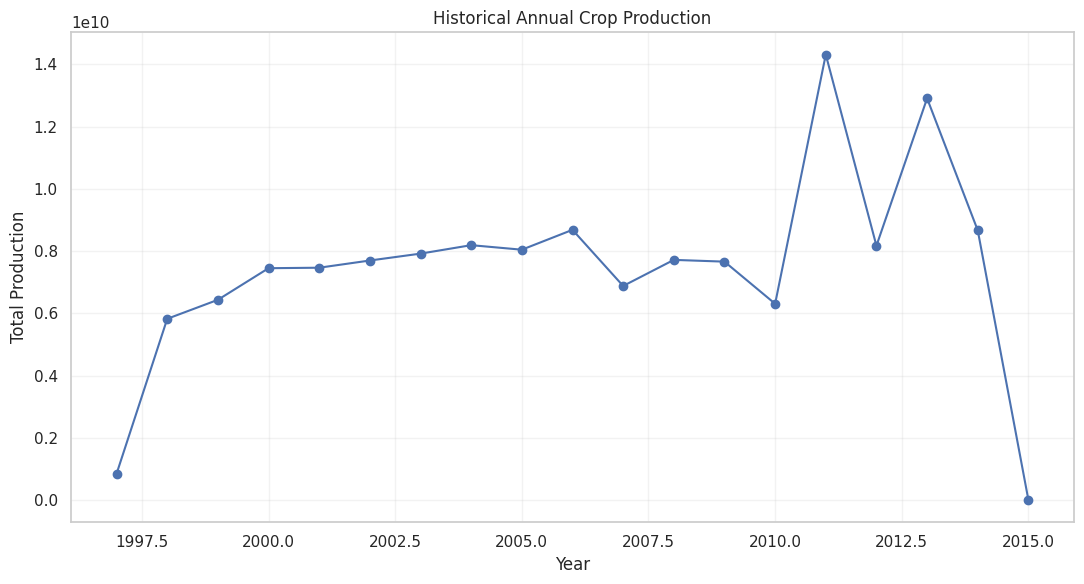

In [10]:
plt.figure(figsize=(11, 6))
plt.plot(
    annual["Crop_Year"],
    annual["Production"],
    marker="o"
)
plt.title("Historical Annual Crop Production")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Year-over-Year Growth

In [11]:
display(annual[["Crop_Year", "YoY_Growth_%"]])

valid_growth = annual.dropna(subset=["YoY_Growth_%"])

print("Largest increase:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmax()])

print("Largest decline:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmin()])


,Crop_Year,YoY_Growth_%
0,1997,NaN
1,1998,584.339221
2,1999,10.460288
3,2000,15.774605
4,2001,0.212515
5,2002,3.099766
6,2003,2.871504
7,2004,3.428759
8,2005,-1.779169
9,2006,7.933554


Largest increase:


,1
Crop_Year,1.998000e+03
Production,5.825321e+09
YoY_Growth_%,5.843392e+02


Largest decline:


,18
Crop_Year,2.015000e+03
Production,6.935065e+06
YoY_Growth_%,-9.991996e+01


## 10. Trend-Based Forecast

In [12]:
forecast_model = LinearRegression()

forecast_model.fit(
    annual[["Crop_Year"]],
    annual["Production"]
)

annual["Trend_Fitted"] = forecast_model.predict(
    annual[["Crop_Year"]]
)

last_year = int(annual["Crop_Year"].max())

future_years = np.arange(
    last_year + 1,
    last_year + 6
)

future = pd.DataFrame({
    "Crop_Year": future_years
})

future["Forecast_Production"] = forecast_model.predict(
    future[["Crop_Year"]]
)

display(future)


,Crop_Year,Forecast_Production
0,2016,9.018101e+09
1,2017,9.176879e+09
2,2018,9.335657e+09
3,2019,9.494435e+09
4,2020,9.653212e+09


## 11. Forecast Model Evaluation

In [13]:
forecast_mae = mean_absolute_error(
    annual["Production"],
    annual["Trend_Fitted"]
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        annual["Production"],
        annual["Trend_Fitted"]
    )
)

forecast_r2 = r2_score(
    annual["Production"],
    annual["Trend_Fitted"]
)

print("Trend-model MAE:", forecast_mae)
print("Trend-model RMSE:", forecast_rmse)
print("Trend-model R²:", forecast_r2)


Trend-model MAE: 1824178577.7301636
Trend-model RMSE: 3004038903.5972233
Trend-model R²: 0.0773281320428878


## 12. Five-Year Forecast Visualization

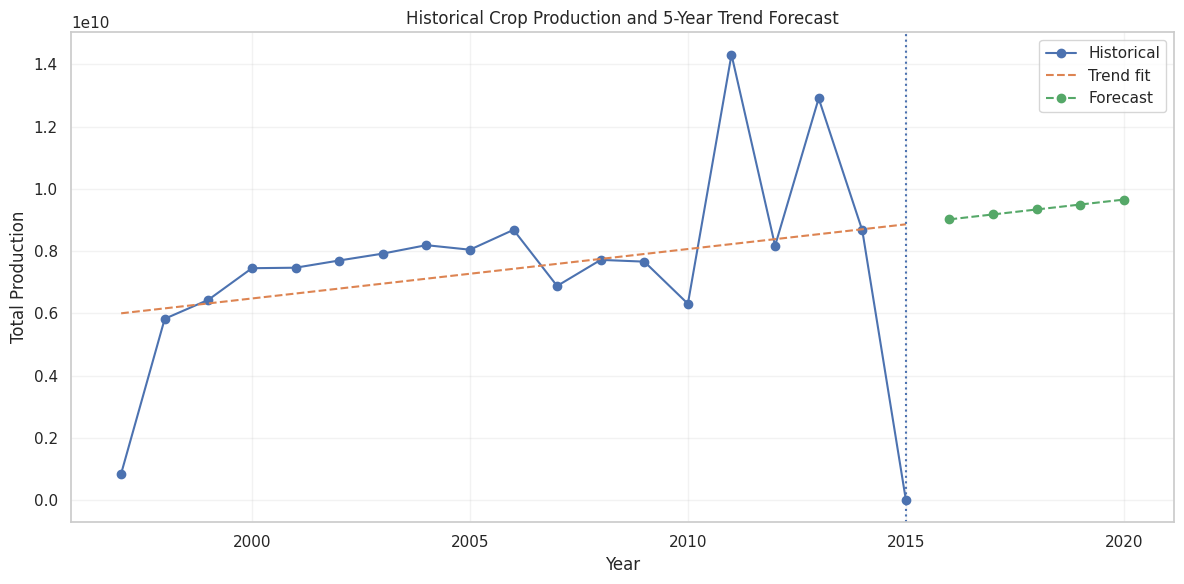

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual["Crop_Year"],
    annual["Production"],
    marker="o",
    label="Historical"
)

plt.plot(
    annual["Crop_Year"],
    annual["Trend_Fitted"],
    linestyle="--",
    label="Trend fit"
)

plt.plot(
    future["Crop_Year"],
    future["Forecast_Production"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    last_year,
    linestyle=":"
)

plt.title("Historical Crop Production and 5-Year Trend Forecast")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 13. Agribusiness Interpretation

Use the statistical outputs to discuss:
- the strength and significance of the Area–Production relationship,
- how well the single-predictor regression explains production,
- years with unusually large year-over-year changes,
- the direction of the annual production trend,
- and how the baseline forecast could support preliminary procurement, storage and logistics planning.

Do not interpret correlation as causation, and do not present the trend forecast as a guaranteed future value.


## 14. Week 3 Conclusion

Week 3 combines inferential statistics, regression analysis and baseline forecasting. The results provide a reproducible statistical benchmark and a starting point for future models that can incorporate weather, prices, irrigation, fertilizer, soil and other agricultural drivers.
